Data Preprocessing

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler

df = pd.read_csv("/content/sample_data/Employee.csv")
print(df.shape)

(148, 6)


Data Exploration

In [5]:
#Unique values and their length
for col in df.columns:
    unique_vals = df[col].unique()
    print(f"\nColumn: {col}")
    print("Unique values:", unique_vals)
    print("Length (count of unique):", len(unique_vals))



Column: Company
Unique values: ['TCS' 'Infosys' 'CTS' nan 'Tata Consultancy Services' 'Congnizant'
 'Infosys Pvt Lmt']
Length (count of unique): 7

Column: Age
Unique values: [20. 30. 35. 40. 23. nan 34. 45. 18. 22. 32. 37. 50. 21. 46. 36. 26. 41.
 24. 25. 43. 19. 38. 51. 31. 44. 33. 17.  0. 54.]
Length (count of unique): 30

Column: Salary
Unique values: [  nan 2300. 3000. 4000. 5000. 6000. 7000. 8000. 9000. 1089. 1234. 3030.
 3045. 3184. 4824. 5835. 7084. 8943. 8345. 9284. 9876. 2034. 7654. 2934.
 4034. 5034. 8202. 9024. 4345. 6544. 6543. 3234. 4324. 5435. 5555. 8787.
 3454. 5654. 5009. 5098. 3033.]
Length (count of unique): 41

Column: Place
Unique values: ['Chennai' 'Mumbai' 'Calcutta' 'Delhi' 'Podicherry' 'Cochin' nan 'Noida'
 'Hyderabad' 'Bhopal' 'Nagpur' 'Pune']
Length (count of unique): 12

Column: Country
Unique values: ['India']
Length (count of unique): 1

Column: Gender
Unique values: [0 1]
Length (count of unique): 2


In [6]:
#Statistical analysis
print(df.describe())
print(df.describe(include='all'))
print(df.info())
print(df.dtypes)

              Age       Salary      Gender
count  130.000000   124.000000  148.000000
mean    30.484615  5312.467742    0.222973
std     11.096640  2573.764683    0.417654
min      0.000000  1089.000000    0.000000
25%     22.000000  3030.000000    0.000000
50%     32.500000  5000.000000    0.000000
75%     37.750000  8000.000000    0.000000
max     54.000000  9876.000000    1.000000
       Company         Age       Salary   Place Country      Gender
count      140  130.000000   124.000000     134     148  148.000000
unique       6         NaN          NaN      11       1         NaN
top        TCS         NaN          NaN  Mumbai   India         NaN
freq        53         NaN          NaN      37     148         NaN
mean       NaN   30.484615  5312.467742     NaN     NaN    0.222973
std        NaN   11.096640  2573.764683     NaN     NaN    0.417654
min        NaN    0.000000  1089.000000     NaN     NaN    0.000000
25%        NaN   22.000000  3030.000000     NaN     NaN    0.000000
5

In [7]:
#Rename columns
df = df.rename(columns={
    'Company': 'company',
    'Age': 'age',
    'Salary': 'salary',
    'Place': 'place',
    'Country': 'country',
    'Gender': 'gender'
})

Data Cleaning

In [9]:
#Find missing / inappropriate values
print(df.isnull().sum())
print(df[df['age'] == 0])          # inappropriate age
print(df['company'].unique())      # inconsistent company names

company     8
age        18
salary     24
place      14
country     0
gender      0
dtype: int64
     company  age  salary       place country  gender
88   Infosys  0.0  3030.0    Calcutta   India       0
92       TCS  0.0  3045.0       Delhi   India       0
101      CTS  0.0  2034.0  Podicherry   India       0
107      TCS  0.0  9024.0     Chennai   India       1
111  Infosys  0.0  3234.0      Mumbai   India       0
121      CTS  0.0  1234.0    Calcutta   India       0
['TCS' 'Infosys' 'CTS' nan 'Tata Consultancy Services' 'Congnizant'
 'Infosys Pvt Lmt']


In [11]:
#Replace age 0 with NaN
df['age'] = df['age'].replace(0, np.nan)

In [20]:
#Treat null values
# Numeric → median
df['age'] = df['age'].fillna(df['age'].median())
df['salary'] = df['salary'].fillna(df['salary'].median())

# Categorical → mode
df['company'] = df['company'].fillna(df['company'].mode()[0])
df['place'] = df['place'].fillna(df['place'].mode()[0])
# Country usually has no nulls; if it does:
df['country'] = df['country'].fillna(df['country'].mode()[0])

display(df)

,company,age,salary,place,country,gender
0,TCS,20.0,5000.0,Chennai,India,0
1,Infosys,30.0,5000.0,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0
...,...,...,...,...,...,...
143,TCS,33.0,9024.0,Calcutta,India,1
144,Infosys,22.0,8787.0,Calcutta,India,1
145,Infosys,44.0,4034.0,Delhi,India,1
146,TCS,33.0,5034.0,Mumbai,India,1


In [21]:
#Fix inconsistent company names
df['company'] = df['company'].replace({
    'Tata Consultancy Services': 'TCS',
    'Infosys Pvt Lmt': 'Infosys',
    'Congnizant': 'CTS',
    'Cognizant': 'CTS'
})
display(df)

,company,age,salary,place,country,gender
0,TCS,20.0,5000.0,Chennai,India,0
1,Infosys,30.0,5000.0,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0
...,...,...,...,...,...,...
143,TCS,33.0,9024.0,Calcutta,India,1
144,Infosys,22.0,8787.0,Calcutta,India,1
145,Infosys,44.0,4034.0,Delhi,India,1
146,TCS,33.0,5034.0,Mumbai,India,1


In [22]:
# Remove duplicate rows
print("Duplicates before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Duplicates before: 4
Shape after removing duplicates: (144, 6)


Age outliers:
 Series([], Name: age, dtype: float64)
Salary outliers:
 Series([], Name: salary, dtype: float64)


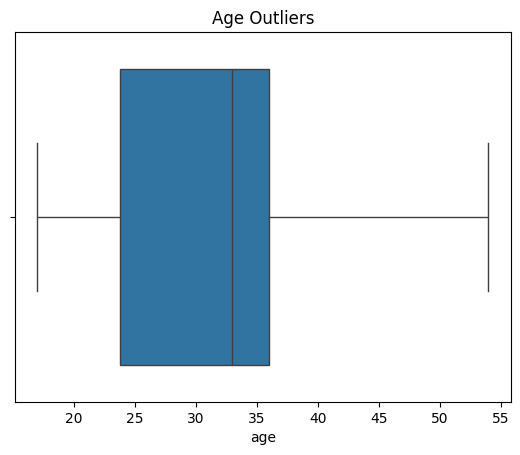

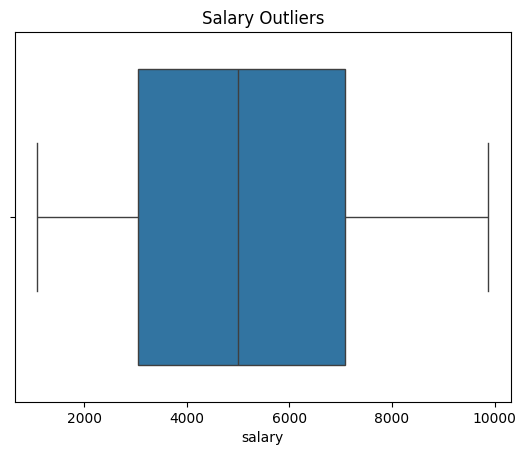

In [25]:
#  Find outliers (IQR method)
def find_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series[(series < lower) | (series > upper)]

print("Age outliers:\n", find_outliers(df['age']))
print("Salary outliers:\n", find_outliers(df['salary']))

# Optional boxplots
sns.boxplot(x=df['age'])
plt.title("Age Outliers")
plt.show()

sns.boxplot(x=df['salary'])
plt.title("Salary Outliers")
plt.show()

Data Analysis

In [27]:
#Filter: age > 40 and salary < 5000
filtered = df[(df['age'] > 40) & (df['salary'] < 5000)]
print(filtered)

     company   age  salary      place country  gender
21   Infosys  50.0  3184.0      Delhi   India       0
32   Infosys  45.0  4034.0   Calcutta   India       0
39   Infosys  41.0  3000.0     Mumbai   India       0
50   Infosys  41.0  3000.0    Chennai   India       0
57   Infosys  51.0  3184.0  Hyderabad   India       0
68   Infosys  43.0  4034.0     Mumbai   India       0
75   Infosys  44.0  3000.0     Cochin   India       0
86   Infosys  41.0  3000.0      Delhi   India       0
93   Infosys  54.0  3184.0     Mumbai   India       0
104  Infosys  44.0  4034.0      Delhi   India       0
122  Infosys  44.0  3234.0     Mumbai   India       0
129  Infosys  50.0  3184.0   Calcutta   India       0
138      CTS  44.0  3033.0     Cochin   India       0
140  Infosys  44.0  4034.0  Hyderabad   India       0
145  Infosys  44.0  4034.0      Delhi   India       1


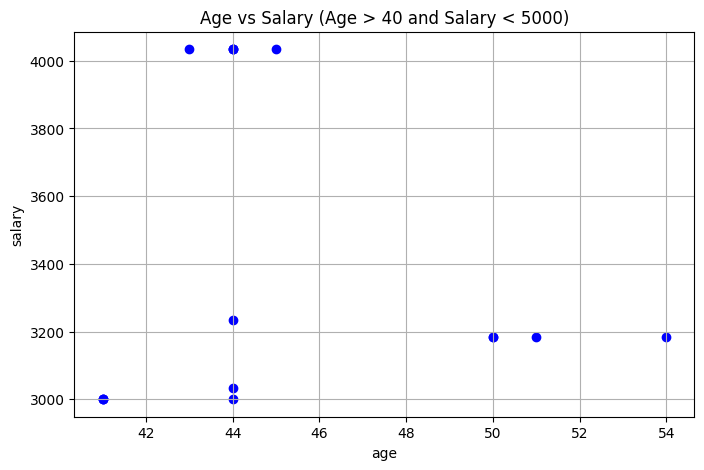

In [29]:
#Plot age vs salary (filtered data)
plt.figure(figsize=(8, 5))
plt.scatter(filtered['age'], filtered['salary'], color='blue')
plt.xlabel('age')
plt.ylabel('salary')
plt.title('Age vs Salary (Age > 40 and Salary < 5000)')
plt.grid(True)
plt.show()

place
Mumbai        48
Calcutta      32
Chennai       14
Delhi         14
Cochin        13
Noida          8
Hyderabad      8
Podicherry     3
Pune           2
Bhopal         1
Nagpur         1
Name: count, dtype: int64


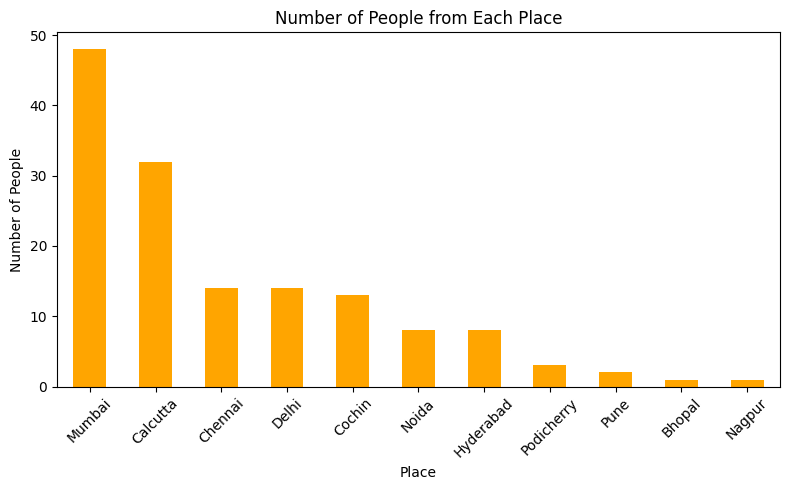

In [31]:
#Count people from each place + chart
place_counts = df['place'].value_counts()
print(place_counts)

place_counts.plot(kind='bar', figsize=(8, 5), color='orange')
plt.xlabel('Place')
plt.ylabel('Number of People')
plt.title('Number of People from Each Place')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Data Encoding

In [40]:
#Label Encoding (one column)

df = df.copy()
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Company_Label'] = le.fit_transform(df['company'])
df['Place_Label'] = le.fit_transform(df['place'])
df['Country_Label'] = le.fit_transform(df['country'])
# Gender is already 0/1 — no need to encode again
df.head()

,company,age,salary,place,country,gender,Company_Label,Place_Label,Country_Label
0,TCS,20.0,5000.0,Chennai,India,0,2,2,0
1,Infosys,30.0,5000.0,Mumbai,India,0,1,6,0
2,TCS,35.0,2300.0,Calcutta,India,0,2,1,0
3,Infosys,40.0,3000.0,Delhi,India,0,1,4,0
4,TCS,23.0,4000.0,Mumbai,India,0,2,6,0


In [36]:
#One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=['company', 'place', 'country'], drop_first=True)
print(df_encoded.head())

    age  salary  gender  Company_Label  Place_Label  Country_Label  \
0  20.0  5000.0       0              2            2              0   
1  30.0  5000.0       0              1            6              0   
2  35.0  2300.0       0              2            1              0   
3  40.0  3000.0       0              1            4              0   
4  23.0  4000.0       0              2            6              0   

   company_Infosys  company_TCS  place_Calcutta  place_Chennai  place_Cochin  \
0            False         True           False           True         False   
1             True        False           False          False         False   
2            False         True            True          False         False   
3             True        False           False          False         False   
4            False         True           False          False         False   

   place_Delhi  place_Hyderabad  place_Mumbai  place_Nagpur  place_Noida  \
0        False        

Feature Scaling

In [38]:
# Select numeric columns to scale
num_cols = ['age', 'salary']

# StandardScaler (mean=0, std=1)
scaler_std = StandardScaler()
df_std = df.copy()
df_std[num_cols] = scaler_std.fit_transform(df[num_cols])
print("After StandardScaler:\n", df_std[num_cols].head())

# MinMaxScaler (range 0 to 1)
scaler_mm = MinMaxScaler()
df_mm = df.copy()
df_mm[num_cols] = scaler_mm.fit_transform(df[num_cols])
print("After MinMaxScaler:\n", df_mm[num_cols].head())

After StandardScaler:
         age    salary
0 -1.484676 -0.100827
1 -0.267174 -0.100827
2  0.341577 -1.243735
3  0.950328 -0.947426
4 -1.119426 -0.524127
After MinMaxScaler:
         age    salary
0  0.081081  0.445089
1  0.351351  0.445089
2  0.486486  0.137817
3  0.621622  0.217480
4  0.162162  0.331285


In [39]:
df.head()

,company,age,salary,place,country,gender,Company_Label,Place_Label,Country_Label
0,TCS,20.0,5000.0,Chennai,India,0,2,2,0
1,Infosys,30.0,5000.0,Mumbai,India,0,1,6,0
2,TCS,35.0,2300.0,Calcutta,India,0,2,1,0
3,Infosys,40.0,3000.0,Delhi,India,0,1,4,0
4,TCS,23.0,4000.0,Mumbai,India,0,2,6,0
